# Lista 03 de Visão Computacional

Beatriz Rodrigues Cavalcante - 22210505

Hugo Coêlho da Silva - 22111533

Link da lista: https://drive.google.com/file/d/1RLlDFoV_hk_BUscJiveLQ8e_TXUyxZl4/view


## Importações e Funções Auxiliares

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
from cv2.typing import MatLike
from pathlib import Path


def show_images(
    *images: np.ndarray,
    titles: list[str] | None = None,
    columns: int = 2,
    scale: int = 5,
) -> None:
    num_images = len(images)

    if titles is None:
        titles = [f"Image {i + 1}" for i in range(num_images)]

    rows = (num_images + columns - 1) // columns

    fig, axes = plt.subplots(rows, columns, figsize=(scale * columns, scale * rows))
    axes = np.array(axes).reshape(rows, columns)

    for ax, img, title in zip(axes.flat, images, titles):
        if img is None:
            ax.axis('off')
            continue
        img_disp = img
        ax.imshow(img_disp, cmap="gray" if img_disp.ndim == 2 else None)
        ax.set_title(title)

    for i in range(num_images, rows * columns):
        fig.delaxes(axes.flat[i])

    plt.tight_layout()

## Questão 1

Nesta questão foi implementada uma adaptação do algoritmo da terceira questão da Lista 02 para alinhamento e montagem (stitching) de imagens em panoramas. Em vez de calcular um score de features, a abordagem detecta keypoints (SIFT), encontra correspondências, estima a homografia e aplica warping para transformar as imagens em um mesmo plano, seguido de blending para suavizar as junções.

Modos de blending disponíveis:
- feather (padrão): transição gradual na região de sobreposição usando um gradiente linear.
- alpha: mistura simples com ponderação 50/50 na região de sobreposição.

O modo "feather" foi escolhido como padrão por oferecer melhor qualidade visual na composição final.

Obs: Apesar da questão pedir para ser feita com trios de imagens o algoritmo permite o uso de mais imagens, no entanto o resultado não fica tão agradável por esticar cada vez mais as imagens a mais a direita.

Referências:
- https://medium.com/@navekshasood/image-stitching-to-create-a-panorama-5e030ecc8f7
- https://marcus888-techstack.github.io/introduction-to-opencv/modules/11-stitching


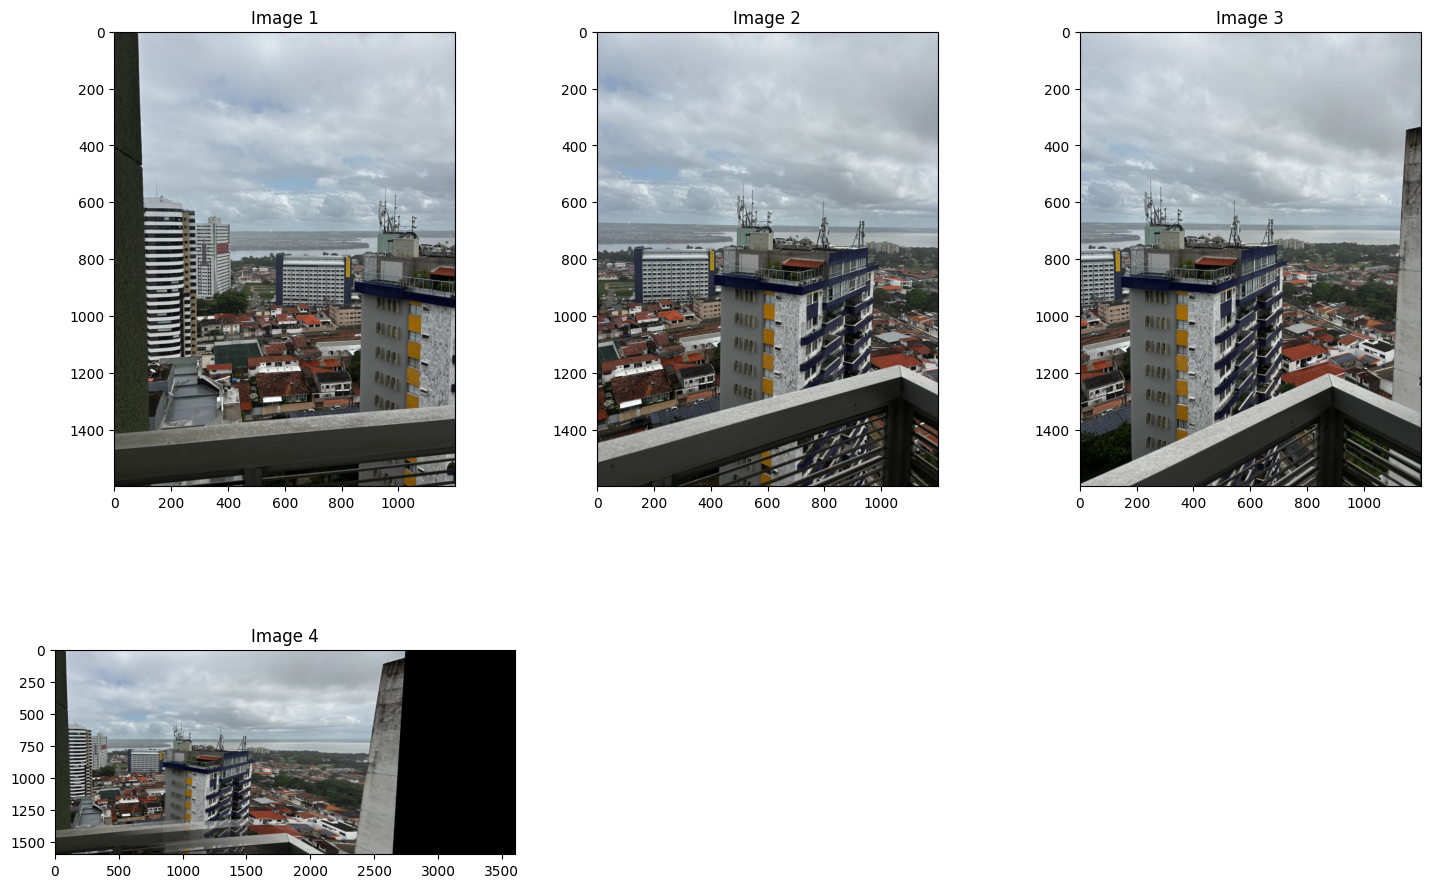

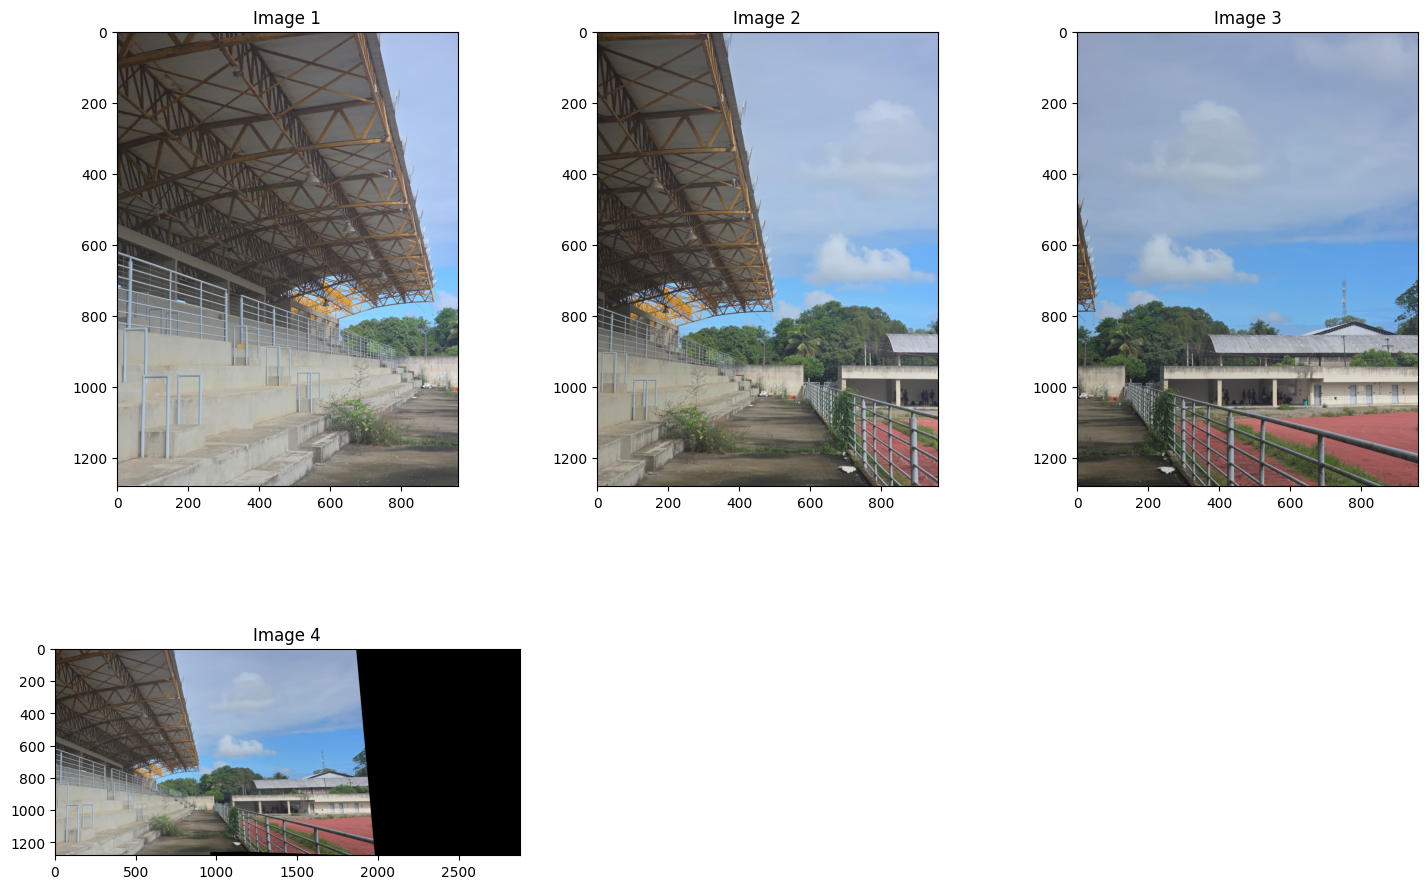

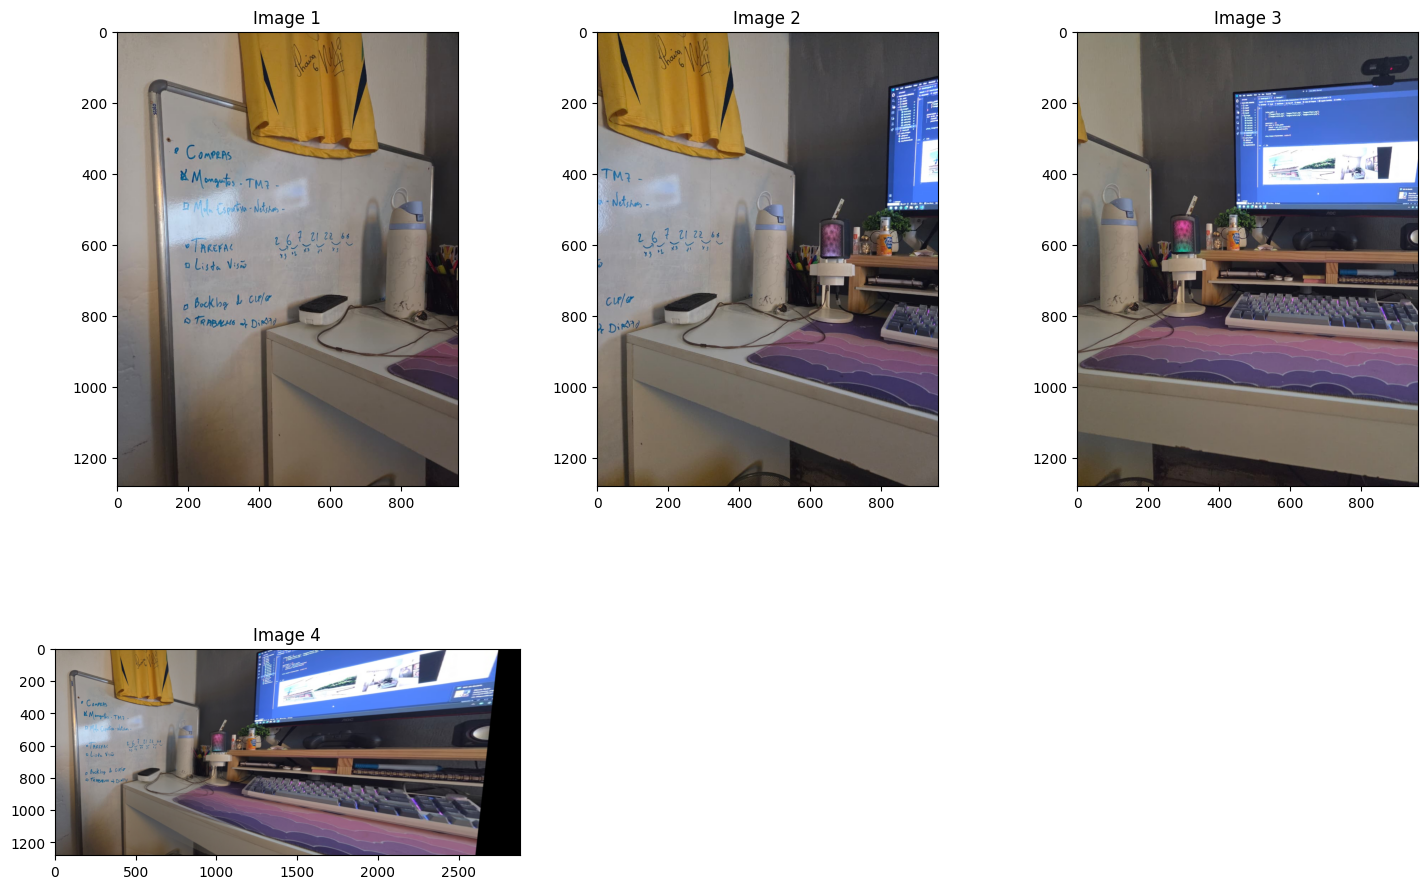

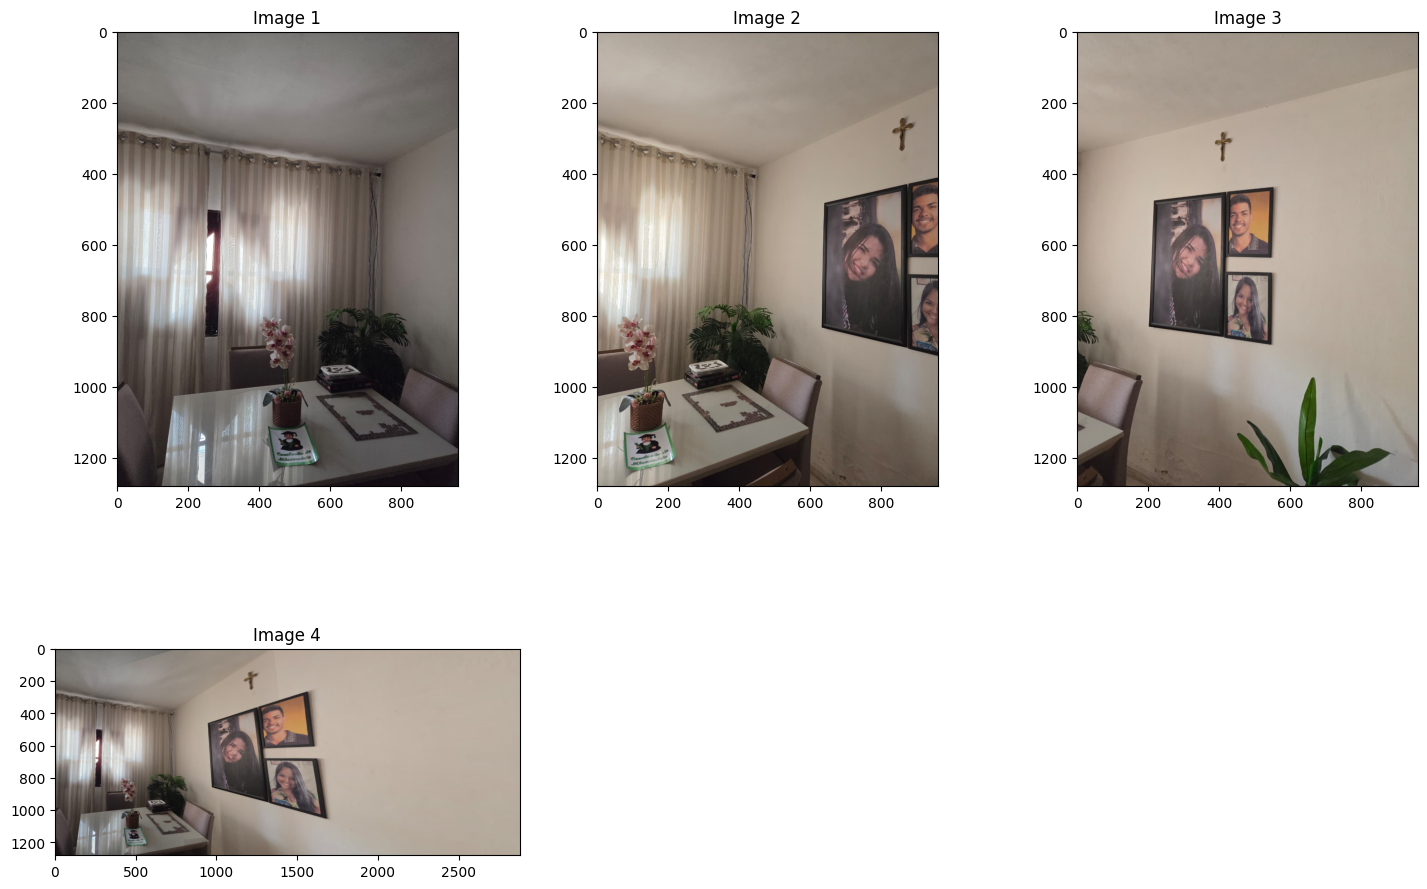

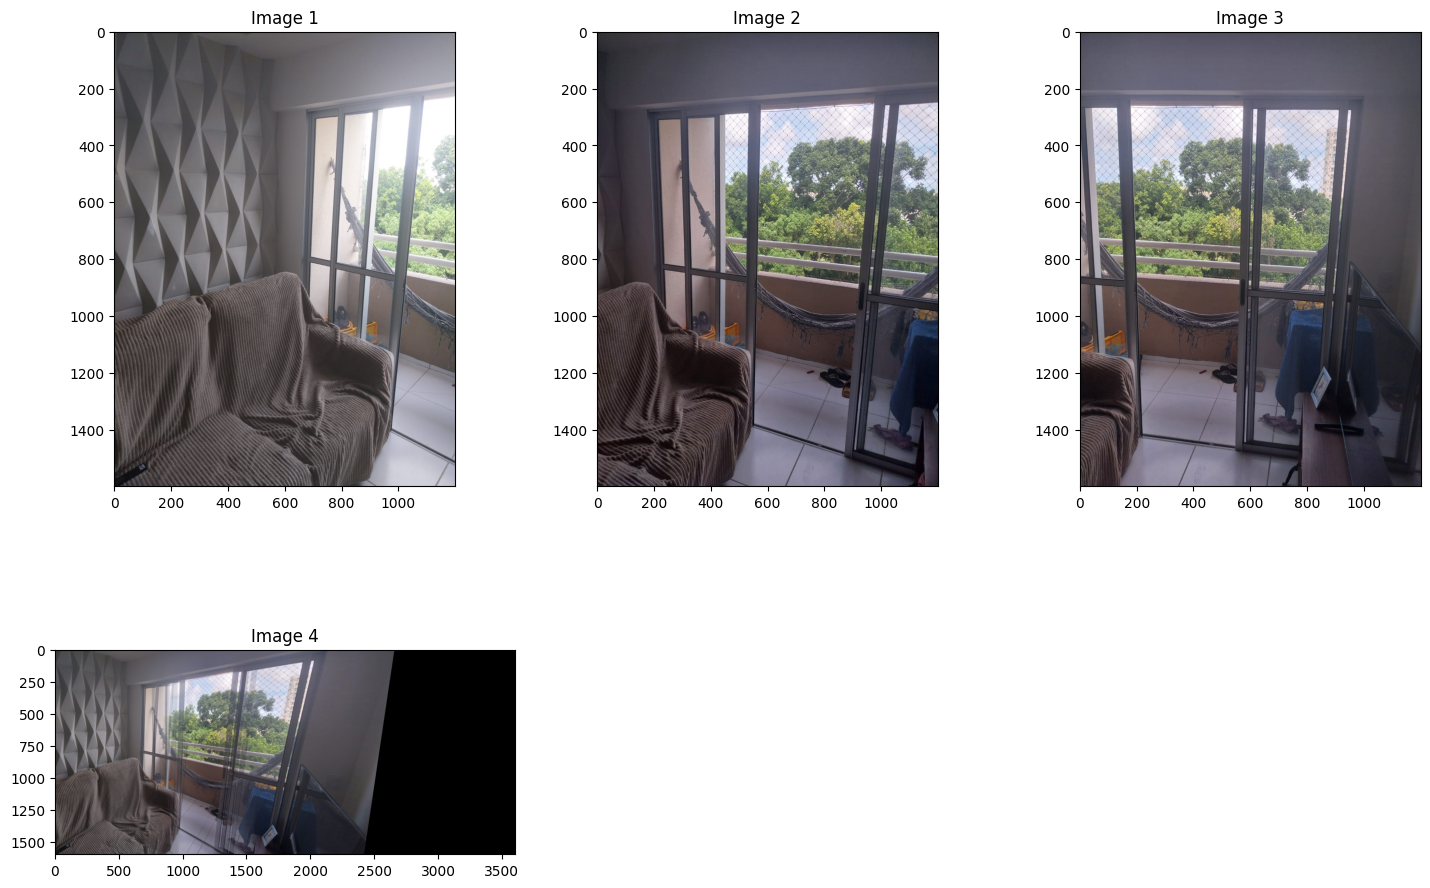

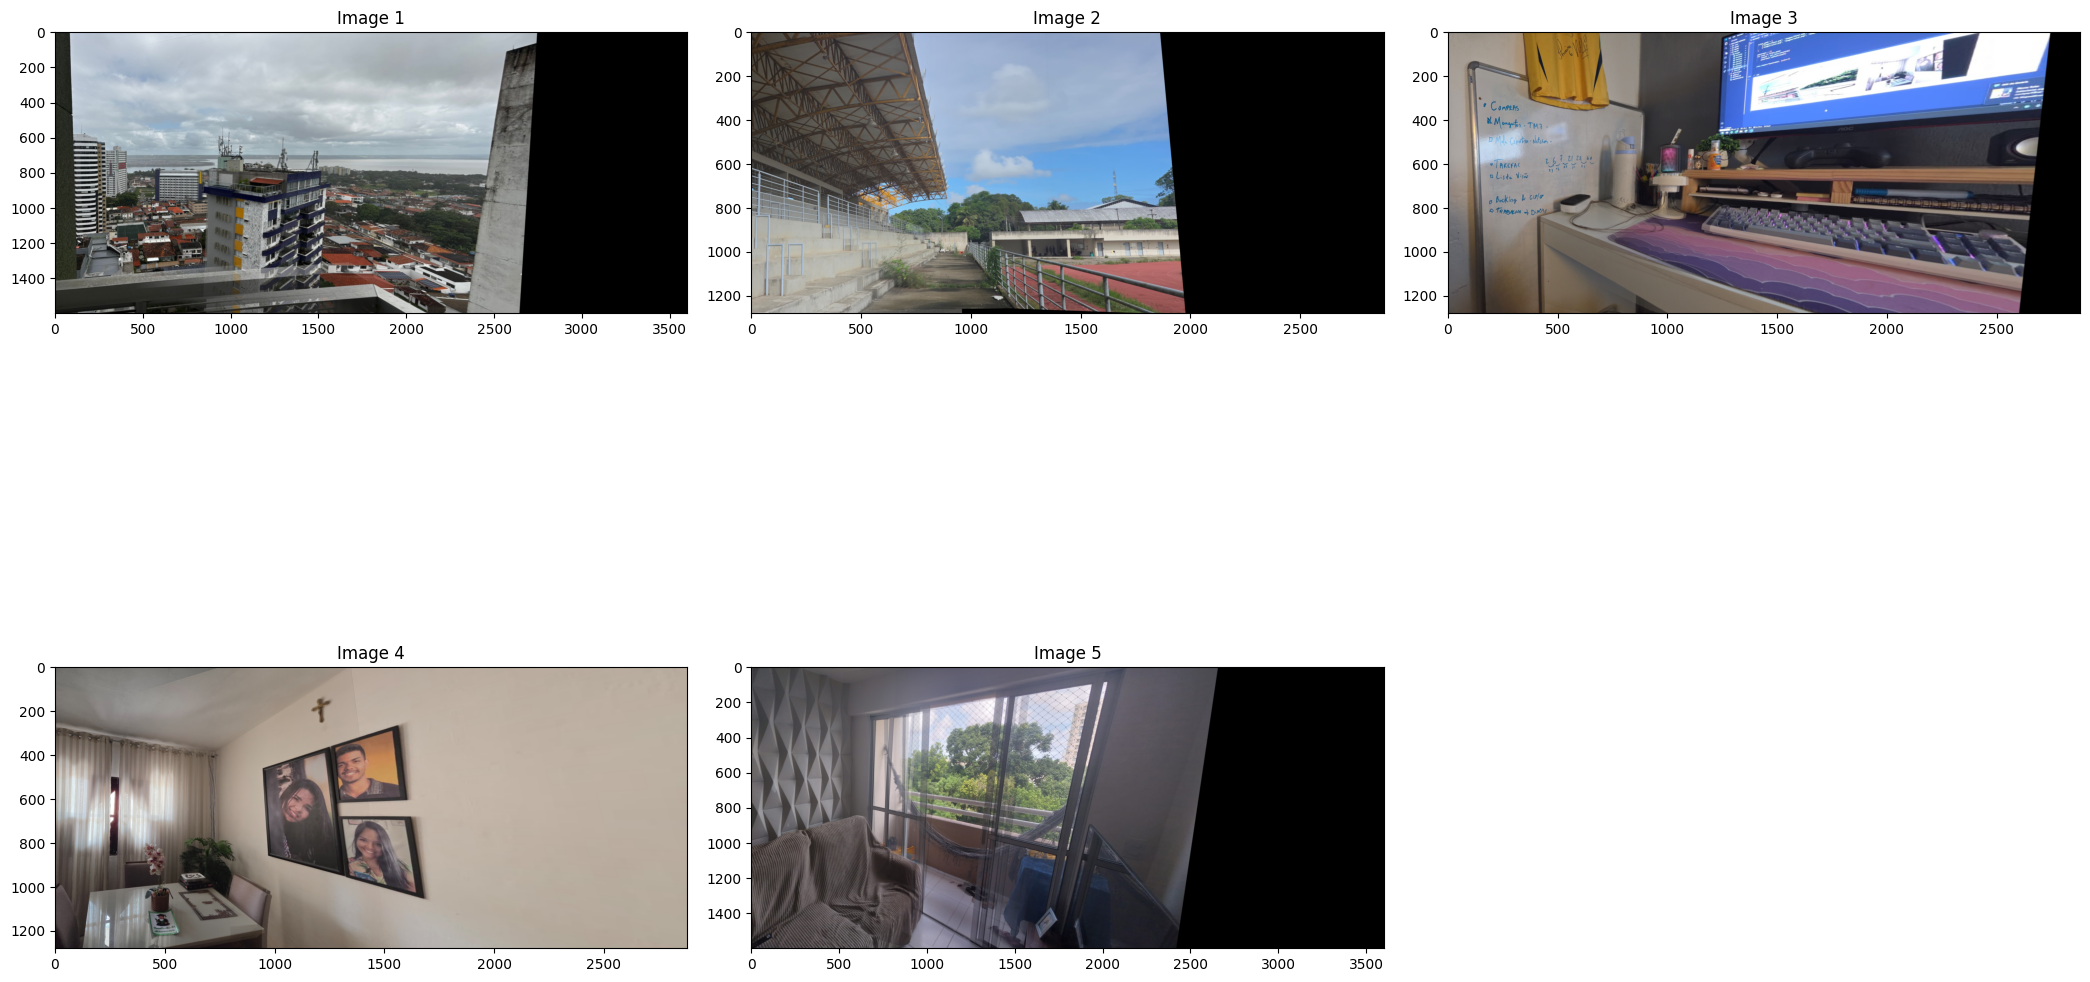

In [7]:
MIN_MATCH_COUNT = 5

def load_imgs(imgs_path: list[str]):
    imgs = []
    for path in imgs_path:
        img = cv.imread(path, cv.IMREAD_COLOR)
        img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
        imgs.append(img)
    return imgs

# Adaptação da implementação trazida da terceira questão da lista 02
def stitch_images_to_panorama(
    left: MatLike,
    right: MatLike,
    blend_mode: str = "feather",
) -> MatLike:
    if left is None or right is None:
        raise FileNotFoundError(
            f"Could not load images {left} or {right}"
        )

    blend_mode = blend_mode.lower()
    if blend_mode not in {"feather", "alpha"}:
        raise ValueError("blend_mode must be 'feather' or 'alpha'")

    left_gray = cv.cvtColor(left, cv.COLOR_BGR2GRAY)
    right_gray = cv.cvtColor(right, cv.COLOR_BGR2GRAY)

    sift = cv.SIFT.create(nfeatures=1000)
    kp1, des1 = sift.detectAndCompute(left_gray, None)
    kp2, des2 = sift.detectAndCompute(right_gray, None)

    matches = cv.BFMatcher().knnMatch(des2, des1, k=2)

    good = []
    for m, n in matches:
        if m.distance < 0.7 * n.distance:
            good.append(m)

    if len(good) < MIN_MATCH_COUNT:
        raise Exception("Not enough matching points")

    pts_src = np.float32([kp2[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
    pts_dst = np.float32([kp1[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)
    H, _ = cv.findHomography(pts_src, pts_dst, cv.RANSAC, 5.0)

    h_left, w_left = left.shape[:2]
    h_right, w_right = right.shape[:2]

    width = w_left + w_right
    height = max(h_left, h_right)

    warped = cv.warpPerspective(right, H, (width, height))

    result_roi = warped[0:h_left, 0:w_left]

    left_valid = np.any(left != 0, axis=2)
    result_valid = np.any(result_roi != 0, axis=2)
    overlap_region = left_valid & result_valid

    blended = result_roi.copy()

    if blend_mode == "alpha":
        if np.any(overlap_region):
            for c in range(3):
                blended[overlap_region, c] = (
                    0.5 * result_roi[overlap_region, c].astype(np.float32)
                    + 0.5 * left[overlap_region, c].astype(np.float32)
                ).astype(np.uint8)
        only_left = left_valid & ~result_valid
        blended[only_left] = left[only_left]
    else:
        if np.any(overlap_region):
            overlap_cols = np.where(np.any(overlap_region, axis=0))[0]
            if overlap_cols.size > 0:
                x0 = int(overlap_cols[0])
                x1 = int(overlap_cols[-1])
                feather_width = max(1, x1 - x0)

                alpha = np.zeros((h_left, w_left), dtype=np.float32)
                ramp = np.clip(
                    (np.arange(w_left, dtype=np.float32) - x0) / feather_width,
                    0.0,
                    1.0,
                )
                alpha[:, :] = ramp[None, :]

                alpha_3 = alpha[..., None]
                blended = (
                    alpha_3 * result_roi.astype(np.float32)
                    + (1.0 - alpha_3) * left.astype(np.float32)
                ).astype(np.uint8)

                only_left = left_valid & ~result_valid
                blended[only_left] = left[only_left]
                only_right = result_valid & ~left_valid
                blended[only_right] = result_roi[only_right]
        else:
            only_left = left_valid & ~result_valid
            blended[only_left] = left[only_left]

    warped[0:h_left, 0:w_left] = blended

    return warped

def gen_panorama(trio_path: list[str], blend_mode: str = "feather") -> MatLike:
    left = cv.imread(trio_path[0], cv.IMREAD_COLOR)
    if left is None:
        raise FileNotFoundError(f"Could not load image {trio_path[0]}")

    for img_path in trio_path[1:]:
        right = cv.imread(img_path, cv.IMREAD_COLOR)
        if right is None:
            raise FileNotFoundError(f"Could not load image {img_path}")
        left = stitch_images_to_panorama(left, right, blend_mode=blend_mode)

    return cv.cvtColor(left, cv.COLOR_BGR2RGB)


panorama_dir = Path("images/panoramas")
image_files = sorted([p for p in panorama_dir.iterdir() if p.suffix.lower() in {".png", ".jpg", ".jpeg"}])
trios_path = [
    [str(image_files[i + j]) for j in range(3)]
    for i in range(0, (len(image_files) // 3) * 3, 3)
]

panoramas = []
for trio in trios_path:
    originals = load_imgs(trio)
    result = gen_panorama(trio, blend_mode="feather")
    panoramas.append(result)
    show_images(*originals, result, columns=3, scale=5)


show_images(*panoramas, scale=7, columns=3)

## Questão 2
Nesta questão, foi implementada uma função para coletar, na imagem, pontos correspondentes aos cantos do campo e às posições dos jogadores. 

A partir desses pontos estimamos a homografia que retifica o campo para um plano 2D (coordenadas reais). Em seguida aplicamos a mesma homografia às posições dos jogadores para obter suas coordenadas no referencial do campo, permitindo calcular a posição real (em metros) dos dois jogadores de uniforme vermelho.

Sendo assim, as coordenadas no mundo real dos dois jogadores de uniforme vermelho é, aproximadamente, (5.69, 13.21) e (2.69, 7.38).

OBS: A OpenCV considera o (0, 0) sendo o canto superior esquerdo, então adaptei as coordenadas e o código para nesse novo ponto.

In [3]:
soccer = cv.imread('images/soccer.png')

if soccer is None:
    raise FileNotFoundError("Could not load image")
    

In [8]:
def click_event(event, x, y, flags, param):
    if event == cv.EVENT_LBUTTONDOWN:
        print(f'Ponto coletado: {x}, {y}')
        cv.circle(soccer, (x, y), 3, (0, 255, 0), -1)
        cv.imshow('Seletor', soccer)


# cv.imshow('Seletor', soccer)
# cv.setMouseCallback('Seletor', click_event)
# cv.waitKey(0)
# cv.destroyAllWindows()


Coordenada Real do Jogador 1 (Metros): [ 5.69557  13.212082]
Coordenada Real do Jogador 2 (Metros): [2.698017 7.381948]


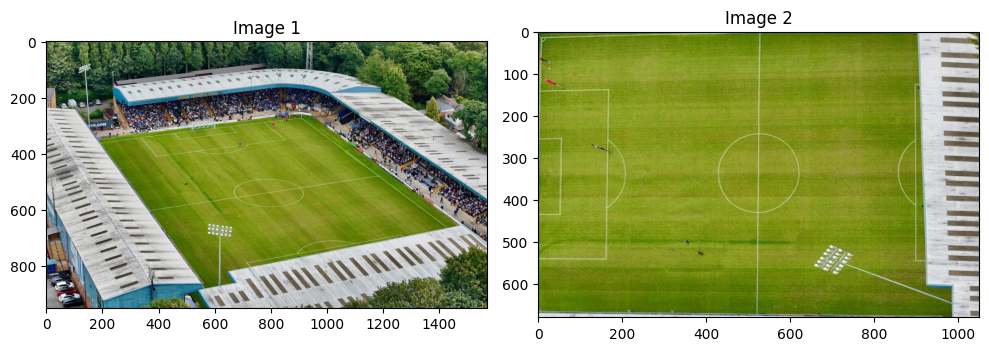

In [10]:
scale = 10

pts_src = np.array([[338, 344], [778, 287], [850, 349], [396, 411]], dtype=np.float32)
pts_dst = np.array([
    [0, 54.15],  
    [0, 13.85],  
    [16.5, 13.85],
    [16.5, 54.15]
], dtype=np.float32)

pts_dst_pixels = pts_dst * scale

H, _ = cv.findHomography(pts_src, pts_dst_pixels)

width, height = 1050, 680
warped_soccer = cv.warpPerspective(soccer, H, (width, height))

show_images(soccer, warped_soccer)

soccer =  cv.cvtColor(soccer, cv.COLOR_BGR2RGB)
warped_soccer =  cv.cvtColor(warped_soccer, cv.COLOR_BGR2RGB)

soccer_players = np.array([[809, 307], [857, 288]], dtype=np.float32)
soccer_players = soccer_players.reshape(-1, 1, 2)
players = cv.perspectiveTransform(soccer_players, H)

player1 = players[0][0] / scale
player2 = players[1][0] / scale

print(f"Coordenada Real do Jogador 1 (Metros): {player1}")
print(f"Coordenada Real do Jogador 2 (Metros): {player2}")


## Questão 3

Nesta questão, foi

## Questão 4

Nesta questão, foi implementado 

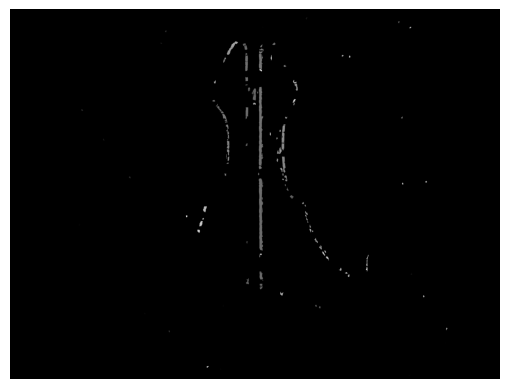

In [36]:
imgL = cv.imread("images/left.png", 0)
imgR = cv.imread("images/right.png", 0)

if imgL is None or imgR is None:
    raise FileNotFoundError("Could not load image")

disparityFactor = 12
stereo = cv.StereoBM.create(numDisparities=16*disparityFactor, blockSize=21)
disparity = stereo.compute(imgL, imgR)
plt.imshow(disparity, 'gray')
plt.show()